In [5]:
%cd /Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code

%pwd




import numpy as np
from typing import Union, Optional, List, Any, Tuple, Callable, Dict
from itertools import product
import pandas
import matplotlib.pyplot as plt

from scipy.sparse.linalg import cg
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml


import landmark
import voltagemap
import problem
import solver
import visualization
import setofpoints
import kmeans
import config



/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


In [8]:
workspace="../../Voltage_Temp/Intermediates/workspace.pkl"
import dill
dill.load_session(workspace)


In [9]:
voltages.shape

(1000,)

In [11]:
def f(x):
    return f"{x:5.3f}"

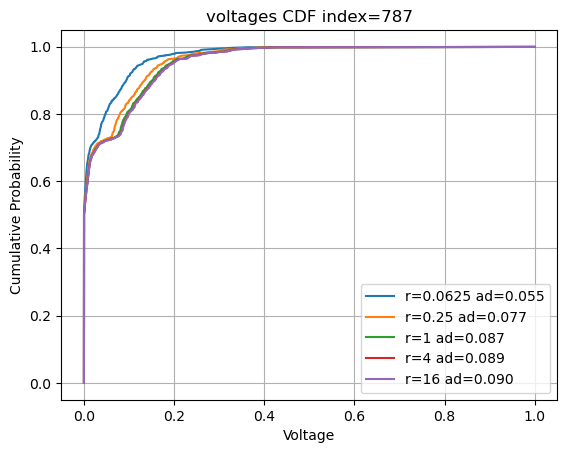

In [13]:
import random
index=random.randint(0, centroids.shape[0])
#index=772 # thin
#index=221,638,363 # fat
#index=772
this_landmark=landmark.Landmark(index,1.0)

from problem import Problem
for i in range(-4,6,2):
    r= 2**i
    _problem=Problem(point_set,r=r)
    volt_solver = solver.Solver(_problem)
    voltages = volt_solver.compute_voltages(this_landmark)
    #plt.hist(voltages.flatten(), bins=100);
    #plot cumulative distribution
    
    
    sorted = np.sort(voltages.flatten())
    low=500
    scaled = (sorted - sorted[low] )/ (sorted[-1] - sorted[low])
    scaled=np.maximum(scaled,0)
    P=np.arange(0,1.00,(1.0/scaled.shape[0]))
    if P.shape[0]>len(scaled):
        P=P[0:len(scaled)]

    advantage=np.mean(scaled[low:])
    plt.plot(scaled,P,label=f"r={r} ad={f(advantage)}")
plt.legend(loc='lower right')
plt.ylabel("Cumulative Probability")
plt.xlabel("Voltage")
plt.title(f"voltages CDF index={index}")
plt.grid()

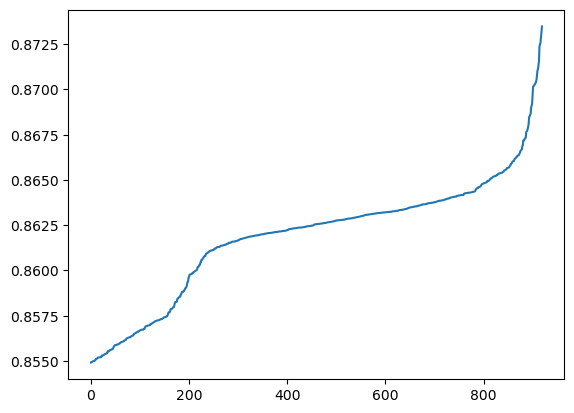

In [251]:
plt.plot(sorted[lim:-lim])